In [1]:
1+1

2

### Build a basic chatbot with langgraph(graph api)

Component of langgraph
    1. Edges
    2. Nodes
    3. State

LLM known for Context generation.

Best way to build ->  1. GRAPH API 2. FUNCTIONAL API


In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b")

In [5]:
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000253927DEAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000253927DF4D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
## node funtionality
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [10]:
graph_builder = StateGraph(State)

# Adding Node
graph_builder.add_node("llmchatbot", chatbot)

# Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#compile the graph
graph = graph_builder.compile()

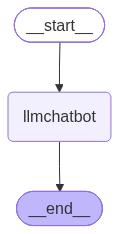

In [8]:
## Visualize the graph

from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed. Please ensure you have the necessary dependencies installed.")
    print(f"Error: {e}")

In [11]:
response = graph.invoke({"messages": [{"role": "user", "content": "Hello, how are you?"}]})

In [13]:
response["messages"]

[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='411ef134-4cac-48a1-8f20-8bd30b695989'),
 AIMessage(content='{\n  "response": "I\'m doing well, thank you! How can I assist you today?",\n  "code": null,\n  "images": []\n}', additional_kwargs={'reasoning_content': 'We need to respond according to the system instructions. The system says: "You are ChatGPT... You must respond to the user in JSON format with keys: "response", "code", "images". The response must be in the "response" field. If there\'s no code, set "code" to null. If no images, set "images" to an empty list. The user says "Hello, how are you?" So we respond with a friendly answer in the response field, code null, images [].\n\nWe need to output JSON only, no extra text. Ensure proper JSON formatting. Probably something like:\n\n{\n  "response": "I\'m doing well, thank you! How can I assist you today?",\n  "code": null,\n  "images": []\n}\n\nYes.'}, response_metadata={'token_usage': 

In [16]:
response["messages"][0]

HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='411ef134-4cac-48a1-8f20-8bd30b695989')

In [14]:
response["messages"][-1]

AIMessage(content='{\n  "response": "I\'m doing well, thank you! How can I assist you today?",\n  "code": null,\n  "images": []\n}', additional_kwargs={'reasoning_content': 'We need to respond according to the system instructions. The system says: "You are ChatGPT... You must respond to the user in JSON format with keys: "response", "code", "images". The response must be in the "response" field. If there\'s no code, set "code" to null. If no images, set "images" to an empty list. The user says "Hello, how are you?" So we respond with a friendly answer in the response field, code null, images [].\n\nWe need to output JSON only, no extra text. Ensure proper JSON formatting. Probably something like:\n\n{\n  "response": "I\'m doing well, thank you! How can I assist you today?",\n  "code": null,\n  "images": []\n}\n\nYes.'}, response_metadata={'token_usage': {'completion_tokens': 201, 'prompt_tokens': 77, 'total_tokens': 278, 'completion_time': 0.422418048, 'completion_tokens_details': {'re

In [20]:
response["messages"][-1].content

'{\n  "response": "I\'m doing well, thank you! How can I assist you today?",\n  "code": null,\n  "images": []\n}'

In [17]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hello, how are you?"}]}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hello! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond. The system says we are ChatGPT, large language model. The user says "Hello, how are you?" So a friendly response. Should be short.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 77, 'total_tokens': 140, 'completion_time': 0.131207118, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.013533068, 'prompt_tokens_details': None, 'queue_time': 0.290439891, 'total_time': 0.144740186}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_acbbc9c4c3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02900-79fb-7653-b30e-ea39d5700e94-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 63, 'total_tokens': 140, 'output_token_details': {'reasoning': 3

In [18]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hello, how are you?"}]}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The system says we are ChatGPT. No special instructions beyond normal. The user says "Hello, how are you?" We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 77, 'total_tokens': 142, 'completion_time': 0.135580569, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.003805835, 'prompt_tokens_details': None, 'queue_time': 0.290462734, 'total_time': 0.139386404}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02901-4a40-7993-885e-1d88d9878566-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 65, 'total_tokens': 142, 'output_token_details': {'reasoning': 3

In [19]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hello, how are you?"}]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I assist you today?


In [21]:
for event in graph.stream({"messages":"Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing well, thank you. How can I assist you today?


### ChatBot with Tool

In [8]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is the recent news about Agentic AI?")

{'query': 'What is the recent news about Agentic AI?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Agentic AI recent news | AI Business',
   'url': 'https://aibusiness.com/generative-ai/agentic-ai',
   'content': 'Jul 15, 2026\n\n|\n\n6 Min Read\n\nPicture of Scarlett Evans\n\nbyScarlett Evans,Contributing Writer\n\nOracle building in Bucharest\n\nAgentic AI\n\nOracle Focuses on Fusion App Developers With Agentic AI Tools\n\nOracle Focuses on Fusion App Developers With Agentic AI Tools\n\nJul 14, 2026\n\n|\n\n3 Min Read\n\nPicture of Shaun Sutner\n\nbyShaun Sutner,Senior News Director, AI Business\n\nIllustration of AI workflow\n\nAgentic AI\n\nUsing AI Agents to Collaborate with Human Workers [...] Agentic AI\n\nMicrosoft Framework to Cut AI Agent Training Costs\n\nMicrosoft Framework to Cut AI Agent Training Costs\n\nAug 4, 2026\n\n|\n\n2 Min Read\n\nPicture of Graham Hope\n\nbyGraham Hope,Contributing Writer\n\nOracle logo on smartphone\n\nA

In [12]:
## Custom Functions
def multiply(a: int, b: int) -> int:
    """"
    Multiplies two integers and returns the result.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.
        
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [13]:
tools = [tool, multiply]

In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000253927DEAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000253927DF4D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

In [27]:
## StateGraph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", tools_condition
)
builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()


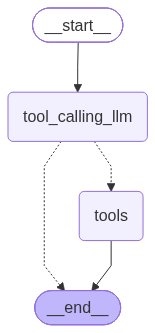

In [28]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
response=graph.invoke({"messages": "What is the recent news about Agentic AI?"})

In [15]:
response["messages"][-1].content

'{"query": "Agentic AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://vegavid.com/blog/latest-developments-in-agentic", "title": "Latest Developments in Agentic AI 2026 | Vegavid", "content": "The pace of innovation in agentic AI has accelerated dramatically over the past year. Recent developments include breakthrough advances in reasoning and planning algorithms, revolutionary multi-agent collaboration frameworks, enhanced tool-use capabilities that allow agents to interact with external systems seamlessly, and sophisticated memory architectures that enable agents to learn from experience and adapt their behavior over time. These innovations are not merely incremental improvements—they represent fundamental shifts in what AI systems can accomplish autonomously. [...] ## Recent Breakthroughs: What\'s New in Agentic AI\\n\\nThe past year has witnessed extraordinary progress across multiple dimensions of agentic AI technology. These 

In [16]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent news about Agentic AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_99da2bc7-2110-465f-b0f7-4e454848c567)
 Call ID: fc_99da2bc7-2110-465f-b0f7-4e454848c567
  Args:
    query: Agentic AI recent news
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "Agentic AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://vegavid.com/blog/latest-developments-in-agentic", "title": "Latest Developments in Agentic AI 2026 | Vegavid", "content": "The pace of innovation in agentic AI has accelerated dramatically over the past year. Recent developments include breakthrough advances in reasoning and planning algorithms, revolutionary multi-agent collaboration frameworks, enhanced 

In [29]:
response=graph.invoke({"messages": "What is 12 multiplied by 8?"})

In [30]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 12 multiplied by 8?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_decfb39e-5f14-4f27-99dd-9134ed79e9f3)
 Call ID: fc_decfb39e-5f14-4f27-99dd-9134ed79e9f3
  Args:
    a: 12
    b: 8
================================= Tool Message =================================
Name: multiply

96


In [32]:
response=graph.invoke({"messages": "What is 12 multiplied by 8 and then multiply by 10?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 12 multiplied by 8 and then multiply by 10?
================================== Ai Message ==================================

\(12 \times 8 = 96\)

\(96 \times 10 = 960\)

So the result is **960**.


In [33]:
response=graph.invoke({"messages": "Give me the recent news about Agentic AI and then multiply 5 by 10."})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent news about Agentic AI and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_935a67ac-50b3-4a0c-8191-0dad87b210b3)
 Call ID: fc_935a67ac-50b3-4a0c-8191-0dad87b210b3
  Args:
    query: Agentic AI recent news
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "Agentic AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://vegavid.com/blog/latest-developments-in-agentic", "title": "Latest Developments in Agentic AI 2026 | Vegavid", "content": "The pace of innovation in agentic AI has accelerated dramatically over the past year. Recent developments include breakthrough advances in reasoning and planning algorithms, revolutionary multi-agent collabora

In [16]:
## StateGraph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph = builder.compile()


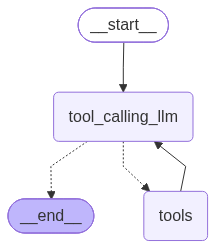

In [35]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
response=graph.invoke({"messages": "Give me the recent news about Agentic AI and then multiply 5 by 10."})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent news about Agentic AI and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_21617a69-0cdd-426f-93a3-3566c7a9f6a5)
 Call ID: fc_21617a69-0cdd-426f-93a3-3566c7a9f6a5
  Args:
    query: Agentic AI recent news
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Agentic AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tcs.com/who-we-are/newsroom/press-release/tcs-launches-agentic-ai-platform-transform-drug-development", "title": "TCS launches Agentic AI platform to transform drug development", "content": "### Want to be a global change-maker? Join our team.\n\nAt TCS, we believe exceptional work begins with hiring, celebrati

### Adding Memory in Agentic Graph

In [17]:
response=graph.invoke({"messages": "Hello, My name is Piyush"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Piyush
================================== Ai Message ==================================

Hello Piyush! Nice to meet you. How can I help you today?


In [18]:
response=graph.invoke({"messages": "What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. Could you let me know what you’d like to be called?


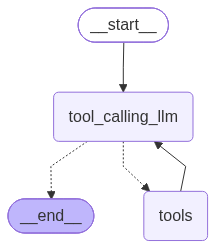

In [19]:
## StateGraph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph = builder.compile(checkpointer=memory)

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages": "Hello, My name is Piyush"}, config=config)

response

{'messages': [HumanMessage(content='Hello, My name is Piyush', additional_kwargs={}, response_metadata={}, id='194f41eb-0fb1-473a-b0cb-6b7aebd1ff66'),
  AIMessage(content='Hello, Piyush! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says hello and introduces themselves. We should respond politely, greet them, maybe ask how we can help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 359, 'total_tokens': 414, 'completion_time': 0.11274115, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.016579108, 'prompt_tokens_details': None, 'queue_time': 0.306503861, 'total_time': 0.129320258}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3166198c1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02dd2-f864-7570-b298-9003d2495c29-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [23]:
response["messages"][-1].content

'Hello, Piyush! Nice to meet you. How can I assist you today?'

In [24]:
response=graph.invoke({"messages": "What is my name?"}, config=config)

print(response["messages"][-1].content)

Your name is Piyush.


### Streaming with memory

Methods : .stream() & .astream()

These methods are sync and async methods for streaming back results.

Additionally, Parameters in streaming modes for graph state
    Values : This streams the full state of the graph after each node
    updates : This streams update to the state of the graph after each node

In [25]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [26]:
def superbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

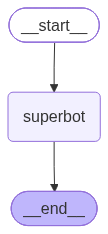

In [27]:
graph = StateGraph(State)
graph.add_node("superbot", superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [28]:
## Invocation of the superbot graph

config = {"configurable":{"thread_id":"1"}}

graph_builder.invoke({"messages": "Hello, My name is Piyush and I like Kabbadi"}, config)

{'messages': [HumanMessage(content='Hello, My name is Piyush and I like Kabbadi', additional_kwargs={}, response_metadata={}, id='390f18ca-2b06-4d30-814d-255485b67fee'),
  AIMessage(content="Hello Piyush! Great to meet you. Kabbadi is such an exciting sport—do you play, or are you more of a fan? I'd love to hear what you enjoy most about it!", additional_kwargs={'reasoning_content': 'The user says "Hello, My name is Piyush and I like Kabbadi". Likely they want a response. We should greet and maybe ask something. No disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 85, 'total_tokens': 180, 'completion_time': 0.200497628, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.004140865, 'prompt_tokens_details': None, 'queue_time': 0.370762243, 'total_time': 0.204638493}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 

In [37]:
# create a new thread and invoke the graph again
config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages": "Hello, My name is Piyush and I like Kabbadi"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Piyush! 👋 Great to meet you. Kabaddi is such an energetic and tactical sport—there’s a lot to love about those quick raids and powerful tackles. \n\nDo you play yourself, or are you more of a fan who follows the leagues and international matches? If you’re looking for training tips, favorite player highlights, or just want to chat about memorable moments in Kabaddi, let me know! I’m here to dive into the action with you.', additional_kwargs={'reasoning_content': 'The user repeatedly says "Hello, My name is Piyush and I like Kabbadi". Likely wants a response acknowledging that. We should respond politely, maybe ask about interest, keep it friendly. No disallowed content. Provide helpful or engaging conversation.'}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 280, 'total_tokens': 439, 'completion_time': 0.325855456, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.011607754, 'prompt_

In [38]:
for chunk in graph_builder.stream({"messages": "Hello, My name is Piyush and I like Kabbadi."}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello, My name is Piyush and I like Kabbadi', additional_kwargs={}, response_metadata={}, id='06c107da-acc3-4fdc-8c17-108fec2752f0'), AIMessage(content="Hi Piyush! 👋 Great to meet you. Kabbadi is such an exciting sport—fast-paced, strategic, and full of energy. Do you play, follow a particular team, or enjoy watching the matches? I'd love to hear more about what you like most about it!", additional_kwargs={'reasoning_content': 'The user says: "Hello, My name is Piyush and I like Kabbadi". Likely they are greeting and sharing personal info. We should respond politely, maybe ask about Kabbadi, show interest. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 85, 'total_tokens': 208, 'completion_time': 0.254242626, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.003638144, 'prompt_tokens_details': None, 'queue_time': 0.282923508, 'total_time': 0.25788077}, 

In [39]:
# create a new thread and invoke the graph again
config = {"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages": "Hello, My name is Piyush and I like Kabbadi"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hi Piyush! Nice to meet you. Kabbadi is such an exciting sport—there’s a lot of skill, strategy, and energy involved. Do you play, coach, or just enjoy watching it? I'd love to hear more about what you like most about kabbadi!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves: "Hello, My name is Piyush and I like Kabbadi". We should respond politely, maybe ask about kabbadi, etc. Follow guidelines: be friendly. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 85, 'total_tokens': 204, 'completion_time': 0.249357832, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.003442145, 'prompt_tokens_details': None, 'queue_time': 0.370121769, 'total_time': 0.252799977}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'gro

In [40]:
for chunk in graph_builder.stream({"messages": "I also like to play Cricket."}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello, My name is Piyush and I like Kabbadi', additional_kwargs={}, response_metadata={}, id='31ee4f58-4e00-45c6-9249-144ec4b80100'), AIMessage(content="Hi Piyush! Nice to meet you. Kabbadi is such an exciting sport—there’s a lot of skill, strategy, and energy involved. Do you play, coach, or just enjoy watching it? I'd love to hear more about what you like most about kabbadi!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves: "Hello, My name is Piyush and I like Kabbadi". We should respond politely, maybe ask about kabbadi, etc. Follow guidelines: be friendly. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 85, 'total_tokens': 204, 'completion_time': 0.249357832, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.003442145, 'prompt_tokens_details': None, 'queue_time': 0.370121769, 'total_time': 0.252799977}, 'model_name': 'openai/gpt-o